In [1]:
import config
import sys
sys.path.append('../util')
import os
from ultralytics import YOLO
from yoloutil import show_yolo_annotation, evaluate_yolo_segmentation, convert_masks_to_yolo_txt

result_path = './yolo11'


In [ ]:
# Create the yolo labels (.txt) here if not already created

# convert_masks_to_yolo_txt(
#     input_dir=config.dataset_path,
#     class_names=["bg","water","sky","land"],
#     multiclass_mode=True, 
#     pixel_map={0:3}
# )


Converting 4814 masks in /home/calculon/0Datasets/lars/dataset-256_v4/labels/train...
Processing /tmp/tmpq6k4bxdr/inhouse_seq_419_00147_orig.png imgsz = 480 x 640
Processed and stored at /home/calculon/0Datasets/lars/dataset-256_v4/labels/train/inhouse_seq_419_00147_orig.txt imgsz = 480 x 640
Processing /tmp/tmpq6k4bxdr/yt089_04_00216_aug0.png imgsz = 256 x 256
Processed and stored at /home/calculon/0Datasets/lars/dataset-256_v4/labels/train/yt089_04_00216_aug0.txt imgsz = 256 x 256
Processing /tmp/tmpq6k4bxdr/mastr_0152_00009_orig.png imgsz = 958 x 1278
Processed and stored at /home/calculon/0Datasets/lars/dataset-256_v4/labels/train/mastr_0152_00009_orig.txt imgsz = 958 x 1278
Processing /tmp/tmpq6k4bxdr/mastr_old_0016_00009_aug0.png imgsz = 256 x 256
Processed and stored at /home/calculon/0Datasets/lars/dataset-256_v4/labels/train/mastr_old_0016_00009_aug0.txt imgsz = 256 x 256
Processing /tmp/tmpq6k4bxdr/yt015_07_00151_aug0.png imgsz = 256 x 256
Processed and stored at /home/calcul

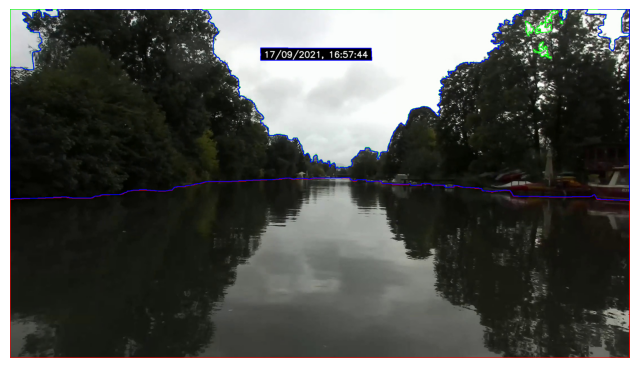

In [2]:
image_path = f"{config.dataset_path}/images/test/davimar_seq_03_00038.jpg"
txt_path   = f"{config.dataset_path}/labels/test/davimar_seq_03_00038.txt"

show_yolo_annotation(image_path, txt_path)


In [ ]:
model = YOLO("yolo11n-seg.pt")

results = model.train(data=f"{config.dataset_path}/data.yaml", 
                      epochs=300, 
                      imgsz=config.dataset_resolution, 
                      patience=20, 
                      project=result_path)

os.system('play -nq -t alsa synth 0.2 sine 600; play -nq -t alsa synth 0.2 sine 600')

In [3]:
model = YOLO(f"{result_path}/train/weights/last.pt")
model.train(resume=True)

Ultralytics 8.3.229 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11770MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/calculon/0Datasets/lars/dataset-256_v4//data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x76b6d8540f70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

You don't need to train YOLO 3 times, because the result will always be the same.

In [11]:
model = YOLO(f"{result_path}/train/weights/best.pt")

In [ ]:
import config
from GenericDatasetReader import get_datasets


_, test_loader, _ = get_datasets(dataset_dir=config.dataset_path, 
                                resolution=config.dataset_resolution, 
                                batch_size=config.batch_size)

metrics = evaluate_yolo_segmentation(model, test_loader, num_classes=config.num_classes)
print(metrics)



Evaluating YOLO Segmentation: 100%|██████████| 13/13 [00:03<00:00,  3.96it/s]

{'F1': 0.459, 'mIoU': 0.415, 'Precision': 0.512, 'Recall': 0.508}


In [6]:
model.info(verbose=True)

YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs


(113, 2834763, 0, 9.5717888)